In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

#Connect and load
conn = sqlite3.connect("../db/nfl_aging.db")
df = pd.read_sql_query("""
    SELECT s.*, p.display_name
    FROM season_stats s
    JOIN players p ON s.player_id = p.player_id
""", conn)
conn.close()

#Center age around the mean — important for mixed models
# This makes the intercept meaningful and helps model convergence
df["age_c"] = df["age"] - df["age"].mean()
df["age_c2"] = df["age_c"] ** 2

print(f"Loaded {len(df)} rows")
print(f"Mean age in dataset: {df['age'].mean():.1f}")
print(f"Age centered — range: {df['age_c'].min():.1f} to {df['age_c'].max():.1f}")

Loaded 1613 rows
Mean age in dataset: 25.8
Age centered — range: -4.8 to 11.2


In [2]:
#Fit mixed-effects model
#Fixed effects: age_c + age_c2 (the population-level aging curve)
#Random effect: player_id (each player gets their own intercept)

model = smf.mixedlm(
    "rushing_yards ~ age_c + age_c2",
    data=df,
    groups=df["player_id"]
)

result = model.fit(reml=True)
print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rushing_yards
No. Observations: 1613    Method:             REML         
No. Groups:       447     Scale:              88153.3676   
Min. group size:  1       Log-Likelihood:     -11701.1149  
Max. group size:  16      Converged:          Yes          
Mean group size:  3.6                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     629.464   15.951 39.464 0.000 598.202 660.727
age_c         -11.006    3.610 -3.049 0.002 -18.081  -3.932
age_c2         -4.921    0.825 -5.963 0.000  -6.538  -3.304
Group Var   54555.392   21.481                             



In [3]:
#Extract coefficients
intercept = result.fe_params["Intercept"]
b1 = result.fe_params["age_c"]
b2 = result.fe_params["age_c2"]

#Calculate peak age
#Peak of a quadratic ax² + bx + c is at x = -b/2a
peak_age_centered = -b1 / (2 * b2)
peak_age = peak_age_centered + df["age"].mean()

print(f"Model coefficients:")
print(f"  Intercept: {intercept:.1f}")
print(f"  Age (linear): {b1:.3f}")
print(f"  Age (squared): {b2:.3f}")
print(f"\nPeak age from model: {peak_age:.1f} years old")
print(f"Predicted yards at peak: {intercept + b1*peak_age_centered + b2*peak_age_centered**2:.1f}")

Model coefficients:
  Intercept: 629.5
  Age (linear): -11.006
  Age (squared): -4.921

Peak age from model: 24.7 years old
Predicted yards at peak: 635.6


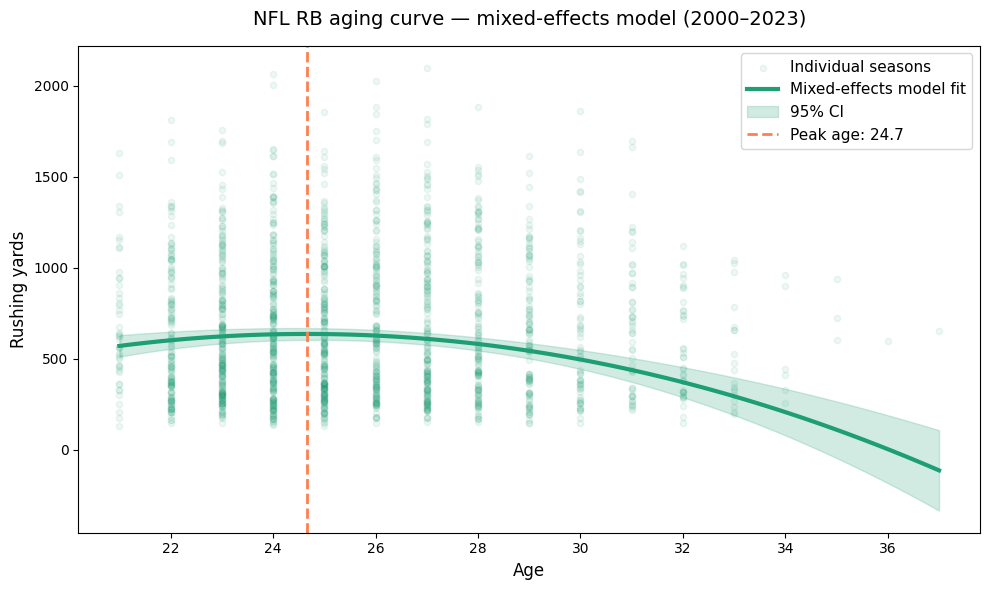

In [4]:
#Plot the fitted aging curve from the model
age_range = np.linspace(df["age"].min(), df["age"].max(), 100)
age_range_c = age_range - df["age"].mean()
age_range_c2 = age_range_c ** 2

#Predicted values from fixed effects
predicted = intercept + b1 * age_range_c + b2 * age_range_c2

#Confidence interval (approximate)
se = np.sqrt(
    result.cov_params().loc["Intercept", "Intercept"] +
    age_range_c**2 * result.cov_params().loc["age_c", "age_c"] +
    age_range_c2**2 * result.cov_params().loc["age_c2", "age_c2"]
)
ci_upper = predicted + 1.96 * se
ci_lower = predicted - 1.96 * se

fig, ax = plt.subplots(figsize=(10, 6))

#Raw data points (faded)
ax.scatter(df["age"], df["rushing_yards"],
           alpha=0.08, color="#1D9E75", s=20, label="Individual seasons")

#Model curve
ax.plot(age_range, predicted, color="#1D9E75",
        linewidth=3, label="Mixed-effects model fit")

#Confidence interval
ax.fill_between(age_range, ci_lower, ci_upper,
                alpha=0.2, color="#1D9E75", label="95% CI")

#Peak age line
ax.axvline(peak_age, color="coral", linestyle="--",
           linewidth=2, label=f"Peak age: {peak_age:.1f}")

ax.set_title("NFL RB aging curve — mixed-effects model (2000–2023)",
             fontsize=14, pad=15)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Rushing yards", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()